In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [ ]:
nu_over_d_vals = np.arange(0.01, 1.0, 0.01)

i = 0
N = 1000
d = 500
for nu_over_d in nu_over_d_vals:
    initial_alpha_X = pp.calculate_alpha_given_nu_over_d_and_d(nu_over_d, d) #, verbose=True)
    print(i, nu_over_d, initial_alpha_X)
    X = pp.generate_data_manifold(N, d, initial_alpha_X, uniform_draws=True, use_pareto=True, use_uniform=False, use_cauchy=False, verbose=False, use_svd=True)
    i += 1

In [5]:

#N = 200
#d = 100
#nu_over_d = 0.5

uniform_draws = True
use_pareto = True
use_uniform = False
use_cauchy = False
verbose = True
use_svd = True


nu_over_d_vals = np.arange(0.01, 1.0, 0.01)
num_iterations = len(nu_over_d_vals)

scale_factor = 200

nu_over_d_X_vals = np.zeros(num_iterations)
nu_over_d_Xnormalised_vals = np.zeros(num_iterations)

i = 0
for nu_over_d in nu_over_d_vals:
	N = int(scale_factor * (3.0 + 2.0 * np.random.uniform(0,1)))
	d = N - int(scale_factor * (2.0 * np.random.uniform(0,1)))
	#print(i, nu_over_d, N, d)

	#print(i, nu_over_d, N, d)
	xx = pp.normalisation_experiment_nu_over_d(N, d, nu_over_d, uniform_draws, use_pareto, use_uniform, use_cauchy, verbose, use_svd)

	nu_over_d_X = xx["nu_over_d_X"]
	nu_over_d_Xnormalised = xx["nu_over_d_Xnormalised"]

	print(i, nu_over_d, nu_over_d_X, nu_over_d_Xnormalised)

	nu_over_d_X_vals[i] = nu_over_d_X
	nu_over_d_Xnormalised_vals[i] = nu_over_d_Xnormalised
	i +=1

initial_alpha_X =  0.5812571986741533
generate_pareto_draws : alpha =  0.5812571986741533
using pareto
[1.00375111 1.00752451 1.0113204  1.01513895 1.01898035]
generate_data_manifold: using svd
0 0.01 0.0076739117187465174 0.014087300660307831
initial_alpha_X =  0.7190957520282586
generate_pareto_draws : alpha =  0.7190957520282586
using pareto
[1.00287437 1.00576298 1.00866592 1.01158329 1.0145152 ]
generate_data_manifold: using svd
1 0.02 0.014227808302012994 0.02470603971111928
initial_alpha_X =  0.8402064795858226
generate_pareto_draws : alpha =  0.8402064795858226
using pareto
[1.00187164 1.00374973 1.00563431 1.00752542 1.00942308]
generate_data_manifold: using svd
2 0.03 0.02095427040020464 0.03309133881438713
initial_alpha_X =  0.8713926618620552
generate_pareto_draws : alpha =  0.8713926618620552
using pareto
[1.00210595 1.00422022 1.00634285 1.00847389 1.01061339]
generate_data_manifold: using svd
3 0.04 0.028112027285186674 0.04470364045113911
initial_alpha_X =  0.9008134307

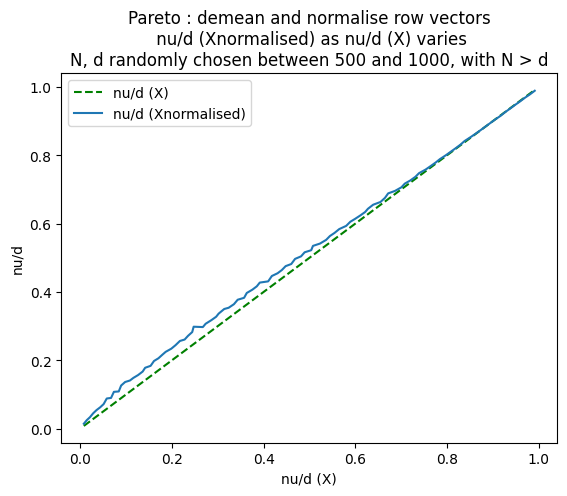

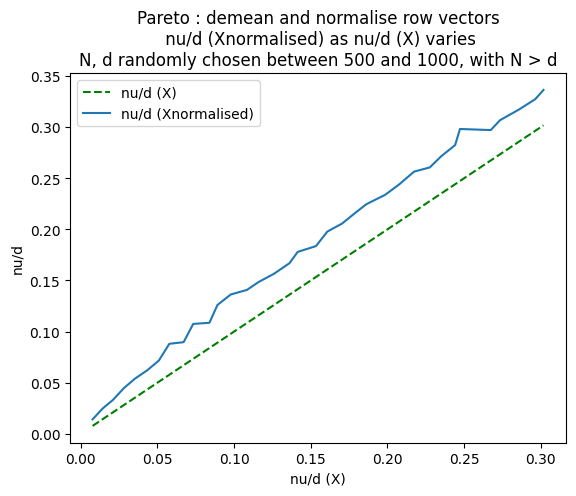

In [17]:
this_title = "Pareto : demean and normalise row vectors\n nu/d (Xnormalised) as nu/d (X) varies\n"
this_title += "N, d randomly chosen between 500 and 1000, with N > d"
plt.plot(nu_over_d_X_vals, nu_over_d_X_vals, color = "green", linestyle = "--", label = "nu/d (X)")
plt.plot(nu_over_d_X_vals, nu_over_d_Xnormalised_vals, label = "nu/d (Xnormalised)")
plt.legend()
plt.xlabel("nu/d (X)")
plt.ylabel("nu/d")
plt.title(this_title)
plt.savefig('nu_over_d_Xnormalised_nu_over_d_X_pareto.pdf', dpi=300, bbox_inches='tight')
plt.show()

k = 35
plt.plot(nu_over_d_X_vals[0:k], nu_over_d_X_vals[0:k], color = "green", linestyle = "--", label = "nu/d (X)")
plt.plot(nu_over_d_X_vals[0:k], nu_over_d_Xnormalised_vals[0:k], label = "nu/d (Xnormalised)")
plt.legend()
plt.xlabel("nu/d (X)")
plt.ylabel("nu/d")
plt.title(this_title)
plt.savefig('nu_over_d_Xnormalised_nu_over_d_X_pareto_two.pdf', dpi=300, bbox_inches='tight')
plt.show()